# E3 — 4-well modified Müller–Brown (10D)

**Target.** The equal-amplitude 4-well Müller–Brown variant (all four Gaussian amplitudes $-200\times0.05$; the true MB's repulsive hump replaced by a fourth well at $(-0.8,-0.5)$ — `archive/mueller.py` precedent), embedded in 10D exactly as before: $U(z) = V_4(z_1,z_2) + \|z_{3:10}\|^2/(2\cdot0.4^2)$, $x = zB^\top$. Unlike the true MB — whose depth gap equals its barrier scale, so *no* temperature is simultaneously multimodal and metastable — this target at $\beta=8$ has masses $p^\star \approx (0.617,\ 0.338,\ 0.027,\ 0.018)$ with a $\beta b = 16.5$ saddle between the two major wells and **plateau-level walls ($\beta b \approx 80$) around the two minor island wells** — locals provably never move, PT needs a deep ladder, and only nonlocal jumps can populate the islands at the right mass. Runs start on island W3 (2.7% mass). Metrics in latent 2D $z_{1:2}$ (full-10D sliced $W_2$ in the CSV).

In [1]:
EXPERIMENT = "mb4well_10d"
import os, sys, math, time, json
sys.path.insert(0, os.path.abspath(".."))
from src.gpu_guard import select_gpu
select_gpu(int(os.environ.get("JCP_GPU", "4")))
import torch
assert torch.cuda.device_count() == 1
torch.set_default_dtype(torch.float64)
import numpy as np
import pandas as pd

from src import config as C
from src.experiments import (build_e3_mb4well, make_sampler_factory,
                             make_batched_factory, make_metrics)
from src.runner import (run_experiment_batched, run_one, refine_dt,
                        quadrature_refinement, write_timeseries_csv,
                        write_summary_csv, write_manifest,
                        ula_first_passage, hardware_manifest)
from src.samplers import tune_ladder
from src.certificate import make_phi_family, certificate_grid, certificate_importance
from src.plotting import metric_grid

DEV = "cuda"
RESULTS = os.path.abspath(os.path.join("..", "results", EXPERIMENT))
FIGURES = os.path.abspath(os.path.join("..", "figures", EXPERIMENT))
os.makedirs(RESULTS, exist_ok=True); os.makedirs(FIGURES, exist_ok=True)
exp = build_e3_mb4well(device=DEV, basin_cache=os.path.join(RESULTS, "basin_map.npz"))
cfg = exp.cfg
print(f"experiment={cfg.name}  d={cfg.d}  N={cfg.n_particles}  T={cfg.T}  dt0={cfg.dt}")
print(f"beta={cfg.beta}  eps={cfg.eps}  lambda={cfg.lam}  seeds={cfg.seeds}")
print(hardware_manifest())

experiment=mb4well_10d  d=10  N=2000  T=200.0  dt0=0.005
beta=8.0  eps=0.125  lambda=1.0  seeds=(0, 1, 2, 3, 4)


{'cpu': 'AMD EPYC 9554 64-Core Processor', 'gpu': 'NVIDIA H200 NVL', 'torch': '2.13.0+cu130', 'cuda': '13.0', 'python': '3.12.13', 'git_sha': 'f2b82bdda370eb43b8d021ddce0ac299a8084948', 'cuda_visible_devices': '7', 'gpu_compute_apps_at_start': ['GPU-c8768979-ae7d-8ca1-a33d-2874c9d21fae, 2955729, 31918 MiB', 'GPU-e003b5e1-3cce-0c27-5a6b-9f594c1b7682, 2955730, 31978 MiB', 'GPU-e003b5e1-3cce-0c27-5a6b-9f594c1b7682, 3212020, 634 MiB', 'GPU-0693e45d-5be4-82d1-e0fa-e72261e24e3b, 2923696, 814 MiB', 'GPU-0693e45d-5be4-82d1-e0fa-e72261e24e3b, 2955731, 31576 MiB', 'GPU-b7477750-5992-8ae3-fde2-11bf70934062, 2801401, 814 MiB', 'GPU-b7477750-5992-8ae3-fde2-11bf70934062, 2955732, 31900 MiB', 'GPU-b7477750-5992-8ae3-fde2-11bf70934062, 3212145, 1160 MiB']}


In [2]:
from src.potentials import MB4_CRITICAL, mb4_2d, mb4_2d_grad, newton_refine
for key, (z_tab, V_tab) in MB4_CRITICAL.items():
    z = newton_refine(mb4_2d_grad, torch.tensor(z_tab, device=DEV))
    Vv = mb4_2d(z.unsqueeze(0))[0].item()
    assert abs(z[0].item()-z_tab[0]) < 5e-5 and abs(z[1].item()-z_tab[1]) < 5e-5, key
    assert abs(Vv - V_tab) < 5e-4, (key, Vv)
    print(f"{key}: ({z[0].item():+.4f}, {z[1].item():+.4f})  V = {Vv:.4f}")
print("p_star (W1..W4):", np.round(exp.p_star.cpu().numpy(), 4),
      " | S12 barrier beta*b = %.1f | island walls beta*b ~ %.0f" %
      (8*(MB4_CRITICAL["S12"][1] - MB4_CRITICAL["W1"][1]),
       8*exp.extras["barrier_W3"]))

# committed first passage from island W3 (expect ZERO local exits)
g = torch.Generator(device=DEV); g.manual_seed(0)
barrier_report = ula_first_passage(exp.pot, exp.box, exp.init_fn(cfg.n_particles, g),
                                   exp.exit_committed, cfg.dt, int(cfg.T/cfg.dt), C.EPS, g)
barrier_report["kramers_tau_plateau"] = exp.kramers_tau
print(f"ULA committed exits from W3: {barrier_report['n_exits']} of "
      f"{barrier_report['n_particles']} in T={cfg.T} "
      f"(plateau-wall estimate: beta*b = {8*exp.extras['barrier_W3']:.0f})")

W1: (+0.0193, +0.4793)  V = -10.4129
W2: (+0.9619, +0.0189)  V = -10.3420
W3: (-0.7979, -0.4943)  V = -10.0334
W4: (-0.5002, +1.4998)  V = -10.0004


S12: (+0.4971, +0.2484)  V = -8.3490
p_star (W1..W4): [0.6173 0.3375 0.0275 0.0178]  | S12 barrier beta*b = 16.5 | island walls beta*b ~ 80


ULA committed exits from W3: 0 of 2000 in T=200.0 (plateau-wall estimate: beta*b = 80)


## Target density: explicit form and visualization

The target is $\pi(x)\propto e^{-\beta U(x)}$ on $\mathbb R^{10}$ at $\beta=8$. In latent coordinates $z = xB^{-\top}$ (equivalently $x = zB^\top$, with $B = Q\,\mathrm{diag}(0.75,\dots,1.45)$ and $Q$ a frozen Haar rotation from `default_rng(12345)`):

$$U(z) \;=\; V_4(z_1,z_2)\;+\;\frac{\|z_{3:10}\|^2}{2\sigma_{\mathrm{aux}}^2},\qquad \sigma_{\mathrm{aux}}=0.4,$$

$$V_4(z_1,z_2) \;=\; \sum_{k=1}^{4} A_k\, \exp\!\big(a_k(z_1-\bar x_k)^2 + b_k(z_1-\bar x_k)(z_2-\bar y_k) + c_k(z_2-\bar y_k)^2\big),$$

with all $A_k=-10$ and

| $k$ | $a_k$ | $b_k$ | $c_k$ | $\bar x_k$ | $\bar y_k$ |
|---|---|---|---|---|---|
| 1 | $-1$   | $0$  | $-10$  | $1$    | $0$    |
| 2 | $-1$   | $0$  | $-10$  | $0$    | $0.5$  |
| 3 | $-6.5$ | $11$ | $-6.5$ | $-0.5$ | $1.5$  |
| 4 | $-3$   | $0$  | $-3$   | $-0.8$ | $-0.5$ |

Because $x = zB^\top$ is an invertible linear map (constant Jacobian), the density factorises **exactly** in latent coordinates:
$$\pi(z)\;=\;\underbrace{\frac{e^{-\beta V_4(z_1,z_2)}}{Z_2}}_{\text{4-well 2D marginal }\pi_2}\;\times\;\prod_{j=3}^{10}\mathcal N\!\left(z_j;\,0,\,\sigma_{\mathrm{aux}}^2\right).$$
All multimodal structure of the 10D target lives in the 2D marginal $\pi_2\propto e^{-\beta V_4}$ plotted below; the well masses $p^\star$ are integrals of $\pi_2$ over the basins and are unchanged by the embedding.

latent-2D grid well masses: [0.6173 0.3375 0.0275 0.0178]  (cf. p_star printed above)


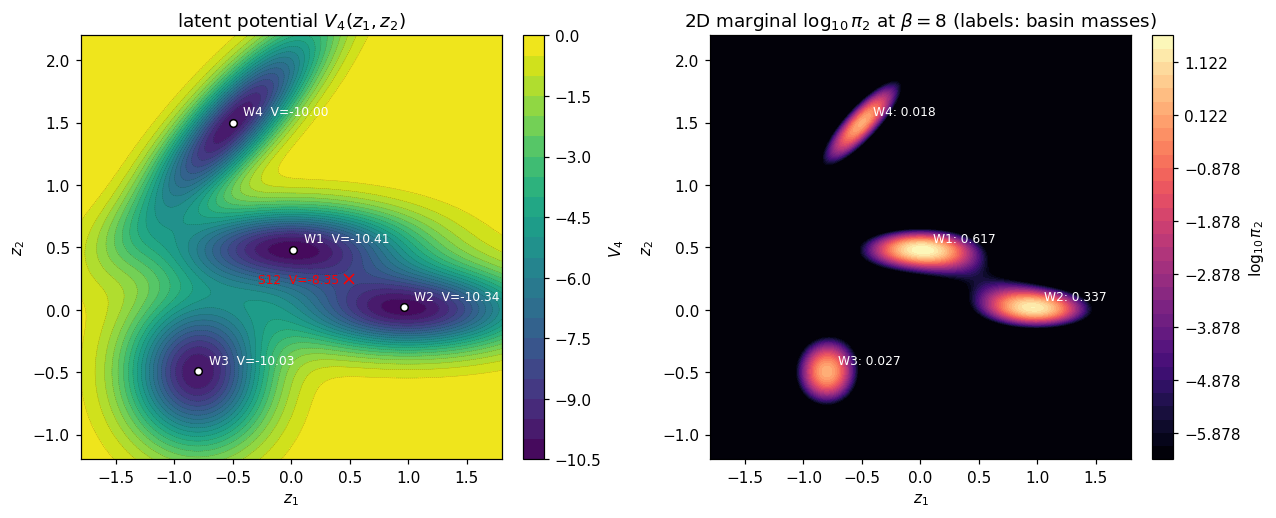

In [ ]:
# Target visualization (self-contained, CPU-safe; touches no run state).
# Exact latent-2D marginal pi_2(z1,z2) ~ exp(-beta V4): the aux coords are
# i.i.d. N(0, 0.4^2) and x = z B^T is linear, so ALL multimodal structure
# of the 10D target is in this 2D density -- no projection artefact.
import os, sys, math
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import torch
import matplotlib.pyplot as plt
from src.potentials import mb4_2d, MB4_CRITICAL

beta_viz = 8.0
zg1 = torch.linspace(-1.8, 1.8, 701, dtype=torch.float64)
zg2 = torch.linspace(-1.2, 2.2, 701, dtype=torch.float64)
ZZ = torch.stack(torch.meshgrid(zg1, zg2, indexing="ij"), dim=-1)
Vg = mb4_2d(ZZ)
cell_area = float((zg1[1] - zg1[0]) * (zg2[1] - zg2[0]))
logp2 = -beta_viz * Vg
logp2 = logp2 - (torch.logsumexp(logp2.reshape(-1), 0) + math.log(cell_area))

# grid well masses via nearest-minimum partition (basins are this tight
# at beta=8); should reproduce the p_star printed above
wells = ["W1", "W2", "W3", "W4"]
zw = torch.tensor([MB4_CRITICAL[k][0] for k in wells], dtype=torch.float64)
lab_g = torch.cdist(ZZ.reshape(-1, 2), zw).argmin(1)
p2_flat = torch.exp(logp2.reshape(-1))
mass = torch.tensor([float(p2_flat[lab_g == i].sum()) for i in range(4)])
mass = mass / mass.sum()
print("latent-2D grid well masses:", np.round(mass.numpy(), 4),
      " (cf. p_star printed above)")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), constrained_layout=True)
lv = np.linspace(-10.5, 0.0, 22)
cf0 = axes[0].contourf(zg1, zg2, Vg.T, levels=lv, cmap="viridis")
axes[0].contour(zg1, zg2, Vg.T, levels=lv, colors="k", linewidths=0.25, alpha=0.4)
for k in wells:
    (zx, zy), Vk = MB4_CRITICAL[k]
    axes[0].plot(zx, zy, "o", ms=5, mfc="w", mec="k")
    axes[0].annotate(f"{k}  V={Vk:.2f}", (zx, zy), textcoords="offset points",
                     xytext=(7, 5), fontsize=8, color="w")
(sx, sy), Vs = MB4_CRITICAL["S12"]
axes[0].plot(sx, sy, "x", ms=7, color="r")
axes[0].annotate(f"S12  V={Vs:.2f}", (sx, sy), textcoords="offset points",
                 xytext=(-7, -3), ha="right", fontsize=8, color="r")
axes[0].set(title=r"latent potential $V_4(z_1, z_2)$", xlabel="$z_1$", ylabel="$z_2$")
fig.colorbar(cf0, ax=axes[0], label="$V_4$")

l10 = (logp2 / math.log(10.0)).numpy()
lv1 = np.linspace(l10.max() - 8.0, l10.max(), 33)
cf1 = axes[1].contourf(zg1, zg2, np.maximum(l10.T, lv1[0]), levels=lv1, cmap="magma")
for k, m in zip(wells, mass):
    (zx, zy), _ = MB4_CRITICAL[k]
    axes[1].annotate(f"{k}: {float(m):.3f}", (zx, zy), textcoords="offset points",
                     xytext=(7, 5), fontsize=8, color="w")
axes[1].set(title=r"2D marginal $\log_{10}\pi_2$ at $\beta=8$ (labels: basin masses)",
            xlabel="$z_1$", ylabel="$z_2$")
fig.colorbar(cf1, ax=axes[1], label=r"$\log_{10}\pi_2$")
os.makedirs(os.path.join("..", "figures", "mb4well_10d"), exist_ok=True)
for ext in ("png", "pdf"):
    fig.savefig(os.path.join("..", "figures", "mb4well_10d",
                             "mb4well_10d_target." + ext), dpi=200,
                bbox_inches="tight")
plt.show()

## Jump law and Lévy score

Complete graph over the four latent minima (12 directed atoms $r_a = (\Delta z, 0_8)B^\top$, $w_a = 1/12$, shell $h = 0.1\min\|r_a\|$, $\lambda = 1$), with the CP pair's drift step capped at $2h$ — all three measured E3 design rules apply: every well here carries $\geq 1.8\%$ mass (no negligible relay targets), weights stay $O(1)$ (mass-ratio skew measurably backfires), and the step cap keeps returned landers inside the score tube. Score: generic shell with log-space accumulation; certificate on the exact latent-2D reduction. *Known regime note:* inter-well asymmetries $\beta\Delta V \in [0.6, 3.3]$ put this landscape partly in the measured mid-asymmetry zone where fixed-step tamed integration of the detailed-balance return flux is imperfect; the $\pi$-start hold test below quantifies the resulting stationary offset honestly.

In [3]:
from src.potentials import MB4Latent2D
from src.jumps import ShellJumpLaw
from src.score import ShellScore
potr = MB4Latent2D()
dz = exp.extras["atoms_z"][:, :2]
h_z = exp.extras["h"] * dz.norm(dim=1) / exp.law.atoms.norm(dim=1)
law_r = ShellJumpLaw(dz, exp.law.weights.clone(), h_z)
print("atoms (latent):", np.round(dz.cpu().numpy(), 3).tolist())
print("h =", round(exp.extras["h"], 4), " drift cap (CP pair) =",
      round(exp.cp_drift_cap, 4))
DEFAULT_QUAD = dict(q_theta=C.Q_THETA, q_rho=C.Q_RHO)
phis = make_phi_family(2, [0.1, 0.5], 0.9, DEV)

def cert_e3(q_theta, q_rho):
    score = ShellScore(potr, law_r, cfg.lam, cfg.beta, q_theta, q_rho)
    shifts, logw = law_r.quadrature_shifts(64)
    return certificate_grid(potr, score, shifts, logw, cfg.lam, cfg.beta, phis,
                            [-4.2, -3.9], [4.4, 4.9],
                            n_panels=170, nodes_per_panel=8, chunk=4096)

cert_report = cert_e3(**DEFAULT_QUAD)
print(f"max R = {cert_report['max_residual']:.3e}")
assert cert_report["max_residual"] < 1e-6

atoms (latent): [[0.943, -0.46], [-0.817, -0.974], [-0.519, 1.021], [-0.943, 0.46], [-1.76, -0.513], [-1.462, 1.481], [0.817, 0.974], [1.76, 0.513], [0.298, 1.994], [0.519, -1.021], [1.462, -1.481], [-0.298, -1.994]]
h = 0.0803  drift cap (CP pair) = 0.1606


max R = 7.511e-10


In [4]:
# PT: geometric ladder beta_k = beta * r^(k-1); K tuned so the post-burn-in
# swap acceptance lands in [0.2, 0.4]
gen = torch.Generator(device=DEV); gen.manual_seed(0)
x0_pilot = exp.init_fn(min(512, cfg.n_particles), gen)
pt_betas, ladder_info = tune_ladder(exp.pot, x0_pilot, cfg.dt, exp.box,
                                    C.BETA, exp.pt_beta_min, pilot_steps=20_000)
print(f"PT ladder: K={ladder_info['K']}  r={ladder_info['r']:.4f}  "
      f"beta_K={pt_betas[-1].item():.4f}  swap acceptance={ladder_info['swap_acceptance']:.3f}"
      f"  band_attained={ladder_info['band_attained']}")

PT ladder: K=6  r=0.4782  beta_K=0.2000  swap acceptance=0.249  band_attained=True


In [5]:
# frozen reference sample (size N), frozen sliced-W2 projections, frozen MMD
# bandwidth (median heuristic on the reference); bias floors from 20
# independent reference pairs. EMC convention: exp(H(p_hat))/K for uniform
# p*, 1 - EJS(p_hat, p*) otherwise -- near 1 is better in both cases.
metrics_fn, floors, aux = make_metrics(exp, cfg.n_particles)
emc_target = exp.emc_target
print("p_star:", np.round(exp.p_star.cpu().numpy(), 6),
      " uniform:", exp.uniform_target)
print("MMD bandwidth:", round(aux["bandwidth"], 4))
for k, v in floors.items():
    print(f"  floor {k:>12s}: {v['mean']:.5f} +- {v['std']:.5f}")

p_star: [0.617308 0.337454 0.027455 0.017783]  uniform: False
MMD bandwidth: 0.8317
  floor           W2: 0.07548 +- 0.01747
  floor          MMD: 0.01827 +- 0.00846
  floor           TV: 0.01218 +- 0.00499
  floor          EMC: 0.99976 +- 0.00012
  floor       W2_10d: 0.01362 +- 0.00177


In [6]:
def run_terminal_lsc(**quad):
    f = make_sampler_factory(exp, cfg.dt, pt_betas, score_kwargs=quad)
    n_ = int(round(cfg.T / cfg.dt))
    r_, _ = run_one("LSC-CP", 0, f, n_, n_, cfg.dt, metrics_fn, exp.pot, quiet=True)
    return {k: r_[-1][k] for k in ("W2", "TV", "MMD", "EMC", "W2_10d")}

settings = [dict(q_theta=qt, q_rho=qr) for qt in (8, 16, 32) for qr in (4, 8, 16)]
CHOSEN_QUAD, quad_table = quadrature_refinement(
    settings, run_terminal_lsc, lambda **s: cert_e3(**s)["max_residual"], floors)
print("chosen quadrature:", CHOSEN_QUAD)
display(pd.DataFrame(quad_table).round(6))

chosen quadrature: {'q_theta': 16, 'q_rho': 4}


,q_theta,q_rho,R,W2,TV,MMD,EMC,W2_10d,pass
0,8,4,0.000025,0.098631,0.012591,0.016542,0.999753,0.028954,False
1,8,8,0.000025,0.098567,0.012091,0.016394,0.999781,0.028891,False
2,8,16,0.000025,0.098567,0.012091,0.016394,0.999781,0.028891,False
3,16,4,0.000000,0.090251,0.019237,0.017271,0.999505,0.026793,True
4,16,8,0.000000,0.090263,0.019237,0.017254,0.999505,0.026815,True
5,16,16,0.000000,0.090263,0.019237,0.017254,0.999505,0.026815,True
6,32,4,0.000000,0.105142,0.029737,0.025503,0.999092,0.027659,True
7,32,8,0.000000,0.105750,0.030237,0.025965,0.999070,0.027682,True
8,32,16,0.000000,0.105750,0.030237,0.025965,0.999070,0.027682,True


In [7]:
# dt rule: largest dyadic dt at which every PI-TARGETING method's terminal
# metrics agree with dt/2 (5% / floor-band / 4-sigma noise guards); FLA and
# raw CP have invariant laws != pi and are recorded but do not gate.
# Production: all 5 seeds batched into one (5N)-particle ensemble per method.
MAIN_METRICS = ["W2", "TV", "MMD", "EMC", "W2_10d"]

def run_terminal_all(dt_):
    n_ = int(round(cfg.T / dt_))
    factory = make_sampler_factory(exp, dt_, pt_betas, score_kwargs=CHOSEN_QUAD)
    out = {}
    for m in C.METHODS:
        rows_, _ = run_one(m, 0, factory, n_, n_, dt_, metrics_fn, exp.pot, quiet=True)
        out[m] = {k: rows_[-1][k] for k in MAIN_METRICS}
    print(f"  refine_dt: finished pass at dt={dt_}", flush=True)
    return out

dt_final, dt_table = refine_dt(run_terminal_all, cfg.dt, floors,
                               exclude=("FLA", "CP"))
print("chosen dt:", dt_final)
for row in dt_table:
    print(row)

n_steps = int(round(cfg.T / dt_final))
steps_per_ck = max(1, n_steps // C.N_CHECKPOINTS)
# dense-early checkpoint schedule: the nonlocal transient lives in the
# first ~5% of the run; 40 dense + 48 sparse points, identical across
# methods (measurement cadence only -- no protocol change)
from src.runner import checkpoint_schedule
ck_steps = checkpoint_schedule(n_steps)
bfactory = make_batched_factory(exp, dt_final, pt_betas, cfg.seeds,
                                score_kwargs=CHOSEN_QUAD)
t0 = time.time()
rows, method_info = run_experiment_batched(C.METHODS, cfg.seeds, bfactory,
                                           n_steps, steps_per_ck, dt_final,
                                           metrics_fn, exp.pot,
                                           cfg.n_particles,
                                           checkpoint_steps=ck_steps)
print(f"production total: {time.time()-t0:.0f}s")
assert max(r["nonfinite_frac"] for r in rows) == 0.0
print("nonfinite fraction: identically zero")

  refine_dt: finished pass at dt=0.005


  refine_dt: finished pass at dt=0.0025


chosen dt: 0.005
{'dt': 0.005, 'pass': True, 'failures': [], 'excluded_deviations': [('FLA', 'MMD', 0.475445, 0.396579), ('FLA', 'W2_10d', 0.21563, 0.199498), ('CP', 'W2_10d', 0.251159, 0.235319)]}


ULA: done in 31.2s (batched 5 seeds)


MALA: done in 56.8s (batched 5 seeds)


...

BAOAB: done in 32.9s (batched 5 seeds)


PT: done in 61.4s (batched 5 seeds)


CP: done in 42.9s (batched 5 seeds)


LSC-CP: done in 301.9s (batched 5 seeds)


production total: 562s
nonfinite fraction: identically zero


In [8]:
# pi-start hold test: initialise at the reference and measure any stationary
# drift of the discretised LSC-CP chain (mid-asymmetry honesty check)
g_h = torch.Generator(device=DEV); g_h.manual_seed(777)
x_pi = exp.ref_sample(4000, g_h)
from src.metrics import occupancy as _occ
bf = make_batched_factory(exp, dt_final, pt_betas, (0,), n_particles=4000,
                          score_kwargs=CHOSEN_QUAD)
s_h = bf("LSC-CP")
s_h.x = x_pi.clone()
p0 = _occ(exp.labels_fn(s_h.positions()), 4)
for _i in range(int(round(100.0 / dt_final))):
    s_h.step()
p1 = _occ(exp.labels_fn(s_h.positions()), 4)
hold_tv = 0.5 * float((p1 - exp.p_star).abs().sum())
pi_start_hold = {"init": [round(float(v), 4) for v in p0],
                 "after_T100": [round(float(v), 4) for v in p1],
                 "TV_vs_pstar": round(hold_tv, 4)}
print("pi-start hold:", pi_start_hold)

pi-start hold: {'init': [0.62, 0.3387, 0.0265, 0.0148], 'after_T100': [0.6312, 0.3292, 0.0298, 0.0097], 'TV_vs_pstar': 0.0162}


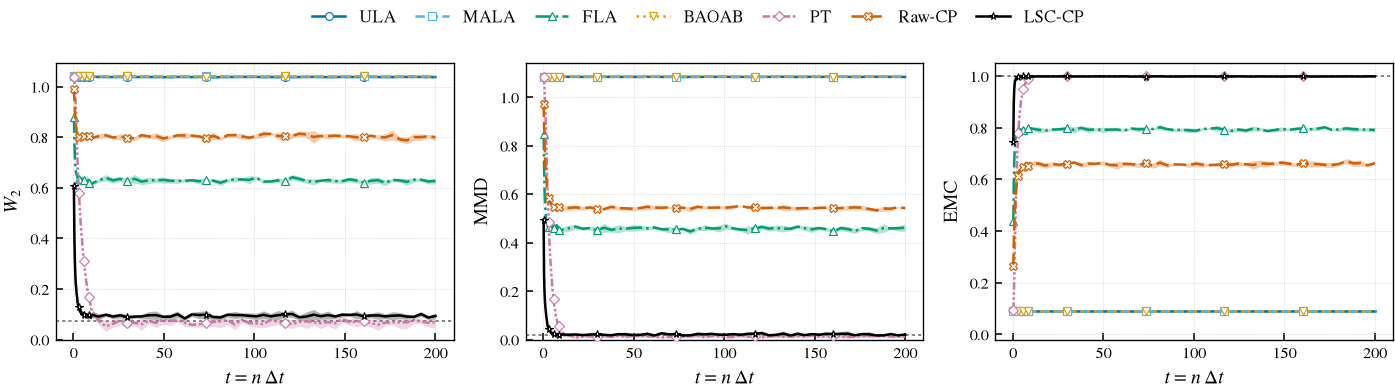

saved: /home/zheyuanlai/levy-sampling/JCP_experiments/figures/mb4well_10d/mb4well_10d_metrics.{png,pdf}


In [9]:
fig = metric_grid(rows, os.path.join(FIGURES, EXPERIMENT + "_metrics"),
                  metrics=("W2", "MMD", "EMC"), floors=floors,
                  emc_target=emc_target)
print("saved:", os.path.join(FIGURES, EXPERIMENT + "_metrics") + ".{png,pdf}")

In [10]:
ts_path = os.path.join(RESULTS, "metrics_timeseries.csv")
write_timeseries_csv(rows, ts_path)
summary_metrics = MAIN_METRICS + ["nonfinite_frac"]
summary = write_summary_csv(rows, C.METHODS, cfg.seeds, summary_metrics,
                            method_info, floors, os.path.join(RESULTS, "summary.csv"))

manifest = dict(
    experiment=EXPERIMENT,
    config=dict(d=cfg.d, N=cfg.n_particles, T=cfg.T, dt0=cfg.dt, dt=dt_final,
                beta=cfg.beta, eps=cfg.eps, lam=cfg.lam, seeds=list(cfg.seeds),
                n_checkpoints=C.N_CHECKPOINTS, warmup_steps=C.N_WARMUP_STEPS,
                batched_seeds=True),
    quadrature=dict(chosen=CHOSEN_QUAD, table=quad_table),
    dt_refinement=[{k: (str(v) if isinstance(v, tuple) else v) for k, v in row.items()}
                   for row in dt_table],
    pt_ladder={k: v for k, v in ladder_info.items()},
    certificate=cert_report,
    bias_floors=floors,
    barrier_verification=barrier_report,
    method_info={m: {k: v for k, v in mi.items() if isinstance(v, (int, float))}
                 for m, mi in method_info.items()},
    hardware=hardware_manifest(),
    pi_start_hold=pi_start_hold,
)
write_manifest(os.path.join(RESULTS, "manifest.json"), **manifest)
print("wrote", ts_path)
from IPython.display import display
display(pd.read_csv(os.path.join(RESULTS, "summary.csv")).round(5))

wrote /home/zheyuanlai/levy-sampling/JCP_experiments/results/mb4well_10d/metrics_timeseries.csv


,method,EMC_mean,EMC_std,MMD_mean,MMD_std,TV_mean,TV_std,V_evals_per_step,W2_10d_mean,W2_10d_std,...,jump_count_mean,m_clip_fraction,mala_accept,nonfinite_frac_mean,nonfinite_frac_std,pt_swap_accept,score_quad_evals_per_step,time_to_threshold_TV,wallclock_mean_s,wallclock_std_s
0,ULA,0.09128,0.00000,1.08417,0.00053,0.97255,0.00000,0.0,0.33677,0.00035,...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,inf,28.83768,0.0
1,MALA,0.09128,0.00000,1.08549,0.00056,0.97255,0.00000,10000.0,0.33740,0.00031,...,NaN,NaN,0.87933,0.0,0.0,NaN,0.0,inf,54.32624,0.0
2,FLA,0.79170,0.00933,0.46164,0.01510,0.42876,0.01236,0.0,0.21013,0.00696,...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,inf,32.59461,0.0
3,BAOAB,0.09128,0.00000,1.08525,0.00046,0.97255,0.00000,0.0,0.33721,0.00040,...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,inf,30.41825,0.0
4,PT,0.99969,0.00022,0.01253,0.00609,0.00964,0.00165,60000.0,0.01289,0.00248,...,NaN,NaN,0.77950,0.0,0.0,0.24839,0.0,13.96,58.89541,0.0
5,CP,0.66319,0.00903,0.54273,0.00549,0.56596,0.00926,0.0,0.24781,0.00400,...,0.00503,NaN,NaN,0.0,0.0,NaN,0.0,inf,40.41466,0.0
6,LSC-CP,0.99889,0.00036,0.02094,0.00560,0.02624,0.00765,0.0,0.02541,0.00073,...,0.00503,0.0,NaN,0.0,0.0,NaN,7680000.0,8.50,299.37993,0.0
